<a href="https://colab.research.google.com/github/SAfsana/COVID-19-EDA/blob/main/Copy_of_Recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving OnlineRetail.csv.zip to OnlineRetail.csv.zip


In [ ]:
import zipfile
import os

with zipfile.ZipFile("OnlineRetail.csv.zip", "r") as zip_ref:
    zip_ref.extractall("online_retail")

print(os.listdir("online_retail"))

['OnlineRetail.csv']


In [ ]:
df = pd.read_csv(
    "online_retail/OnlineRetail.csv",
    encoding="latin1"
)

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [ ]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Rows and columns: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [ ]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
df = df.dropna(subset=["CustomerID", "Description"])

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (406829, 8)


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5225


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (401604, 8)


In [ ]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print("Shape after removing cancelled transactions:", df.shape)

Shape after removing cancelled transactions: (392732, 8)


In [ ]:
df = df[df["Quantity"] > 0]

print("Shape after removing invalid quantities:", df.shape)

Shape after removing invalid quantities: (392732, 8)


In [ ]:
print(df.head())
print("\nFinal shape:", df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

Final shape: (392732, 8)


In [ ]:
customer_product = df.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

print(customer_product.head())

Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
CustomerID                                                                    
12346.0                                   0                               0   
12347.0                                   0                               0   
12348.0                                   0                               0   
12349.0                                   0                               0   
12350.0                                   0                               0   

Description   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
CustomerID                                                      
12346.0                       0                             0   
12347.0                       0                             0   
12348.0                       0                             0   
12349.0                       0                             0   
12350.0                       0                         

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(customer_product.T)

print(product_similarity.shape)

(3877, 3877)


In [ ]:
similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)

print(similarity_df.head())

Description                     4 PURPLE FLOCK DINNER CANDLES  \
Description                                                     
4 PURPLE FLOCK DINNER CANDLES                        1.000000   
50'S CHRISTMAS GIFT BAG LARGE                        0.000000   
DOLLY GIRL BEAKER                                    0.000021   
I LOVE LONDON MINI BACKPACK                          0.000228   
I LOVE LONDON MINI RUCKSACK                          0.000000   

Description                     50'S CHRISTMAS GIFT BAG LARGE  \
Description                                                     
4 PURPLE FLOCK DINNER CANDLES                        0.000000   
50'S CHRISTMAS GIFT BAG LARGE                        1.000000   
DOLLY GIRL BEAKER                                    0.003534   
I LOVE LONDON MINI BACKPACK                          0.004001   
I LOVE LONDON MINI RUCKSACK                          0.000000   

Description                     DOLLY GIRL BEAKER  \
Description                        

In [ ]:
def recommend_products(product_name, n=5):

    if product_name not in similarity_df.columns:
        return "Product not found in the dataset."

    recommendations = (
        similarity_df[product_name]
        .sort_values(ascending=False)
        .iloc[1:n+1]
    )

    return recommendations

In [ ]:
print(df["Description"].dropna().unique()[:20])

['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' 'KNITTED UNION FLAG HOT WATER BOTTLE'
 'RED WOOLLY HOTTIE WHITE HEART.' 'SET 7 BABUSHKA NESTING BOXES'
 'GLASS STAR FROSTED T-LIGHT HOLDER' 'HAND WARMER UNION JACK'
 'HAND WARMER RED POLKA DOT' 'ASSORTED COLOUR BIRD ORNAMENT'
 "POPPY'S PLAYHOUSE BEDROOM " "POPPY'S PLAYHOUSE KITCHEN"
 'FELTCRAFT PRINCESS CHARLOTTE DOLL' 'IVORY KNITTED MUG COSY '
 'BOX OF 6 ASSORTED COLOUR TEASPOONS' 'BOX OF VINTAGE JIGSAW BLOCKS '
 'BOX OF VINTAGE ALPHABET BLOCKS' 'HOME BUILDING BLOCK WORD'
 'LOVE BUILDING BLOCK WORD' 'RECIPE BOX WITH METAL HEART']


In [ ]:
recommend_products(
    "WHITE HANGING HEART T-LIGHT HOLDER",
    5
)

,WHITE HANGING HEART T-LIGHT HOLDER
Description,
GIN + TONIC DIET METAL SIGN,0.750192
RED HANGING HEART T-LIGHT HOLDER,0.658714
WASHROOM METAL SIGN,0.643520
LAUNDRY 15C METAL SIGN,0.642200
GREEN VINTAGE SPOT BEAKER,0.631463


In [ ]:
product_name = "WHITE HANGING HEART T-LIGHT HOLDER"

recommendations = recommend_products(product_name, 5)

print("Product:", product_name)
print("\nRecommended Products:")

for i, product in enumerate(recommendations.index, 1):
    print(i, ".", product)

Product: WHITE HANGING HEART T-LIGHT HOLDER

Recommended Products:
1 . GIN + TONIC DIET METAL SIGN
2 . RED HANGING HEART T-LIGHT HOLDER
3 . WASHROOM METAL SIGN
4 . LAUNDRY 15C METAL SIGN
5 . GREEN VINTAGE SPOT BEAKER


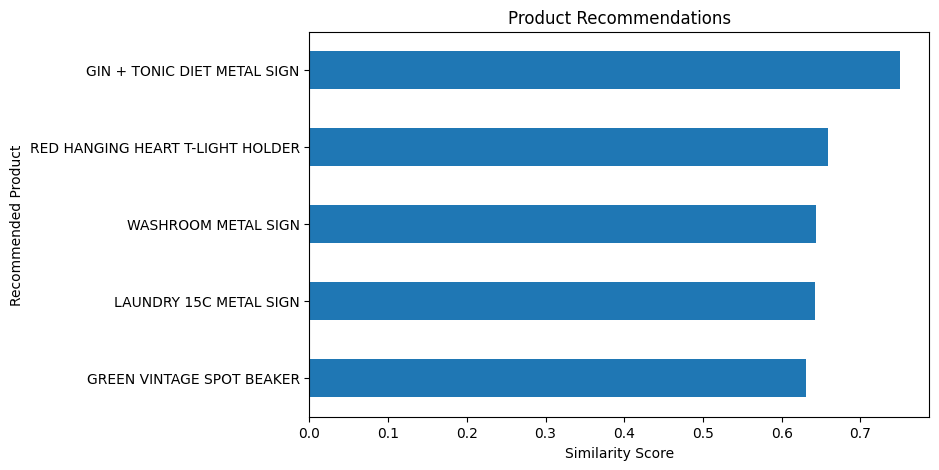

In [ ]:
import matplotlib.pyplot as plt

recommendations.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.xlabel("Similarity Score")
plt.ylabel("Recommended Product")
plt.title("Product Recommendations")
plt.show()

In [ ]:
recommendations_df = recommendations.reset_index()

recommendations_df.columns = [
    "Recommended Product",
    "Similarity Score"
]

recommendations_df.to_csv(
    "product_recommendations.csv",
    index=False
)

print("Recommendations saved successfully.")

Recommendations saved successfully.
